Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menu bar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menu bar, select Cell$\rightarrow$Run All).

Below, please fill in your name and collaborators:

In [1]:
NAME = "Cameron Turner"
COLLABORATORS = ""

# Assignment 3 - Time Series Analysis
**(15 points total)**

## Assignment tasks:

In this assignment you will conduct time series analysis of the financial data. 

1. Setup your environment to access and download latest stock data. Please see instructions below for different tools you can use to get the data. You can use any of the options provided, either Quandl or Yahoo Finance. If you know of any other service to download the data, please use that service, provide an explanation in the comments.

2. *(2 points)* Download the **adjusted** close prices for FB, MMM, IBM and AMZN for the last 60 months. If you run into any issues downloading the data from online sources, you can use `.csv` files provided. This will not affect your grade for the assignment.

3. *(3 points)* Resample the data to get prices for the end of the **business** month. Select the **Adjusted Close** for each stock.

4. *(3 points)* Use the pandas `autocorrelation_plot()` function to plot the autocorrelation of the adjusted month-end close prices for each of the stocks.
    - Are they autocorrelated?
    - Provide short explanation.

5. *(4 points)* 
    - Calculate the monthly returns for each stock using the "shift trick" explained in the lecture, using `shift()` function. 
    - Use pandas `autotocorrelation_plot()` to plot the autocorrelation of the monthly returns.
    - Are the returns autocorrelated? Provide short explanation.

6. *(3 points)*
    - Combine all 4 time series (returns) into a single DataFrame,
    - Visualize the correlation between the returns of all pairs of stocks using a scatter plot matrix (use `scatter_matrix()` function from `pandas.plotting`).
    - Explain the results. Is there any correlation?

**NOTES:** 
1. In this assignment, please make sure the DataFrame(s) do not contain any NAs before you plot autocorrelations or scatter matrix.
2. Both options explained below use `pandas-datareader` package for remote data access. To install it, type the following in a command window: `conda install pandas-datareader`. You will also need to install one or more of the following packages `fix_yahoo_finance`, `quandl`. See below.

---------

## Downloading Stock Prices

### Option 1 - Using QUANDL

To use QUANDL service, you need to create an account and get an API Key. Here is the short description of steps:

- Go to https://www.quandl.com/
- Click either `sign up` at the top right corner of the home page, or scroll all the way down and click `Create Free Account` button at the bottom of the page.
- Create an account. 
- You will receive an email to the email address you have used during the registration. Confirm your email.

You are all set.

Now, as you login into your account, click the avatar icon at the top right corner of the page, select `"Account Settings."`
On the next page, you will see `Your API Key` field with a long string of numbers and characters underneath. You need this API key for your call to Quandl from the notebook. In the code below, replace `YOUR_API_KEY` with the actual API key from your account. 

**NOTE**: You can remove this key before submitting the assignment.

In [2]:
# NOTE:
#
# The first several cells below are commented out as they will be implemented in the 
# Python class below.  
#
# The option chosen for downloading Stock Prices is Option 2, using the Yahoo Finance Library.
#


# all imports and env variables
#import pandas as pd
#pd.core.common.is_list_like = pd.api.types.is_list_like
#import datetime
#from matplotlib import pyplot as plt

#import pandas_datareader.data as web

# This line of code should work on Windows and Mac
#%env QUANDL_API_KEY = "YOUR_API_KEY"

# If the above line of code does not work on your system,
# You can use this way of setting Quandl env variable
#import quandl
#quandl.ApiConfig.api_key = "YOUR_API_KEY"

In [3]:
# Make sure you adjust the start and end date accordingly
# so that the start date = today date

#start = datetime.datetime(2013, 11, 12)
#end = datetime.datetime(2018, 11, 12)

#amzn = web.DataReader('WIKI/AMZN', 'quandl', start, end)

### Option 2 - Using Yahoo Finance `yfinance` library

In [4]:
#import yfinance as yf
#from pandas_datareader import data as pdr

# 1) Using pandas datareader and Yahoo Finance
#yf.pdr_override()

#amzn = pdr.get_data_yahoo('AMZN', start = start)


In [5]:
# 2) Using fix_yahoo_finance library only to download AMZN data

#amzn = yf.download('AMZN', start=start)
#print (type(amzn))
#amzn.head()

In [6]:
# If we want to download multipe stocks into a single dataframe:

#all_stocks_list = ['AMZN', 'META']
#all_stocks = yf.download(all_stocks_list, start = start)
#all_stocks.head()

In [7]:
## START OF CODE
##

In [8]:
# Import libraries.
#
import pandas as pd
pd.core.common.is_list_like = pd.api.types.is_list_like
import datetime
from matplotlib import pyplot as plt
import yfinance as yf
from pandas_datareader import data as pdr

# Class: Stock_Analyzer
#
class Stock_Analyzer:
    
    # Constructor.
    #
    def __init__(self, stock_list, start_date, end_date):
        
        print ("Initializing the Stock Analyzer object.")
        
        self.stock_list = stock_list
        self.start_date = start_date
        self.end_date   = end_date
        self.df = {}
        self.df_all = pd.DataFrame()
        self.df_all_roi = pd.DataFrame()
        self.first_adjClose = {}
    
        print("The Stock Analyzer object has been initialized to use the stocks:", stock_list, "\n")
 

    # Getter method for all stock data.
    #
    def get_dataframe_all_stocks(self):
        
        # Return the dataframe attribute.
        #
        return self.df_all

    
    # Getter method for all ROI data.
    #
    def get_dataframe_all_roi(self):
        
        # Return the dataframe attribute.
        #
        return self.df_all_roi
    
    
    # identify_incomplete_column_data
    #
    def identify_incomplete_column_data(self, stock):
        
        # Print out the columns with null values along with how many records
        # are null for each column.
        #
        pd.options.display.min_rows = 200

        print ('----------------------------')
        print (self.df[stock].isnull().sum().sort_values(ascending=False))
        print ('----------------------------')

        
    # load_data
    #
    def load_data(self):
        
        # Iterate over the stocks in the stock list and load the data
        # from Yahoo Finance.
        #
        for stock in self.stock_list:
            
            # Load the data and reset the index.
            #
            print ("Loading stock data from Yahoo Finance for", stock)
            self.df[stock] = yf.download(stock, start=self.start_date)
            self.df[stock] = self.df[stock].reset_index()
        
    
    # clean_data
    #
    def clean_data(self):
        
        print ("\nCleaning the dataframe")
        print ("----------------------")
        
        # Iterate over the stocks in the stock list and clean the data.
        #
        for stock in self.stock_list:
            
            # Set a temporary dataframe variable to the object's dataframe attribute
            # for readability.
            #
            dfs = self.df[stock]

            # Change the Date column to a datetime object, if not already set.
            #
            dfs['Date'] = pd.to_datetime(dfs['Date'])
            
            # Create a new dataframe based on the Business Month end in the date range.
            #
            df2 = dfs[dfs['Date'].isin(pd.date_range(self.start_date, self.end_date, freq="BM"))]

            # Create a new column in the dataframe to add the stock name.
            #
            df2 = df2.assign(Stock = stock)

            # Create a new dataframe using only the columns that are of interest.
            #
            df_new = df2.loc[:, ['Date', 'Adj Close', 'Stock']].sort_values(by='Date', ascending=True)
            df_new = df_new.reset_index()
            df_new = df_new.rename_axis('', axis='columns')
            df_new = df_new.drop(columns='index')

            # Determine the first Adjusted Close of the stock.  For a 'shift', this would be
            # NaN so we'll impute an adjusted close for the first month's shifted adjusted close
            # as the same value, in essence giving an ROI of 0% since it can be very difficult
            # to accurately calculate an ROI for each month. 
            #
            self.first_adjClose[stock] = df_new.loc[0, 'Adj Close']
            print ("The dataframe has been cleaned and the first Adjusted Close value for", stock, "is ", self.first_adjClose[stock])

            # Reset the dataframe for the stock to the temporary dataframe.
            #
            self.df[stock] = df_new

        print ("----------------------\n")

        
    # plot_autocorrelation_graph
    #
    def plot_autocorrelation_graph(self, stock, column):
            
        # Plot an autocorrelation graph based on the specified column for the specified
        # stock's Time Series.
        #
        stockTimePlot = pd.plotting.autocorrelation_plot(self.df[stock][column])
        stockTimePlot.set_title("Autocorrelation Plot: " + stock +" and " + column)
        stockTimePlot.set_ylabel("Correlation")
        stockTimePlot.set_xlabel("Lag (Months)")

        
    # add_roi
    #
    def add_roi(self):
        
        # Iterate over all the stocks in the stock list.
        #
        for stock in self.stock_list:
         
            # Calculate a shift based on one month ("1") and fill the the first month's
            # Adjusted Close as the original Adjusted Close, thereby, giving an ROI of 0% for
            # the first month as it is quite difficult to predict an ROI for each month.
            #
            dfs = self.df[stock]
            dfs = dfs.assign(LastMonth = dfs['Adj Close'].shift(1, fill_value=self.first_adjClose[stock])) 

            # Create a new column, MonthlyROI, and fill it based on the ROI formula.
            #
            dfs = dfs.assign(MonthlyROI = ((dfs['Adj Close'] - dfs['LastMonth'])/dfs['LastMonth'])*100)
            self.df[stock] = dfs
        
        
    # merge_all_stocks
    #
    def merge_all_stocks(self):
        
        # Iterate over all the stocks in the stock list.
        #
        for stock in self.stock_list:
            
            # Do a vertical merge as all the columns are the same.
            #
            self.df_all = pd.concat([self.df_all, self.df[stock]], axis=0)

            
    # merge_all_stocks_roi
    #
    def merge_all_stocks_roi(self):
        
        # Do a horizontal merge based on Date.
        #
        for stock in self.stock_list:
            
            # Do a horizontal merge on the MonthlyROI columns.
            #
            self.df_all_roi = pd.concat([self.df_all_roi, self.df[stock]['MonthlyROI']], axis=1)
 
        # Rename the columns as they will all originally be "MonthlyROI".
        #
        self.df_all_roi.columns=[self.stock_list[0] + " ROI", self.stock_list[1] + " ROI", self.stock_list[2] + " ROI", self.stock_list[3] + " ROI"]

        
    # print_scatter_plot
    #
    def print_scatter_plot(self, stock, column):
        
        # Print out a single scatter plot for the stock.
        #
        dfs = self.df[stock]
        
        my_scatter_plot = dfs.plot.scatter(x='Date', y=column, c='Green')
        

    # print_scatter_matrix_roi
    #
    def print_scatter_matrix_roi(self):
        
        # Display a scatter matrix for the ROI.
        #
        pd.plotting.scatter_matrix(self.df_all_roi, alpha=0.2, figsize=(10,10))
    
    
    # print_scatter_matrix
    #
    def print_scatter_matrix(self, lag_value):
        
        ax1 = self.df_all.plot.scatter(x='Date',
                                       y='Adj Close',
                                       c=self.df_all['Stock'].map({'IBM':'red','AMZN':'blue', 'META':'green', 'MMM':'purple'}))
            
        pd.plotting.scatter_matrix(self.df_all, alpha=0.2, figsize=(10,10))
        
    
    # print_stock
    #
    def print_stock(self, stock, rows):
        
        print ("Looking for ", stock, "in:", self.stock_list)
        
        # Ensure the stock is in the stock list.
        #
        if (stock in self.stock_list):
            
            # It is, therefore, print out the specified number of rows.
            #
            print (self.df[stock].head(rows))
            
        else:
            
            # The stock is not in the stock list.
            #
            print ("Error: the stock", stock, "is not in the stock list.")
            
          
    # print_all_stocks
    #
    def print_all_stocks(self):

        print (self.df_all)
        
        
    # print_all_roi
    #
    def print_all_roi(self):

        print (self.df_all_roi)



In [9]:
# Main
#

# Set the stock list, start and end dates.
#
my_stock_list = [ "AMZN", "META", "IBM", "MMM"]
start_date = datetime.datetime(2013, 11, 12)
end_date   = datetime.datetime(2018, 11, 12)

# Instantiate an object of the class.
#
my_stock_analyzer = Stock_Analyzer(my_stock_list, start_date, end_date)

# Load and clean the stock data to prepare it for use.
#
my_stock_analyzer.load_data()
my_stock_analyzer.clean_data()


Initializing the Stock Analyzer object.
The Stock Analyzer object has been initialized to use the stocks: ['AMZN', 'META', 'IBM', 'MMM'] 

Loading stock data from Yahoo Finance for AMZN
[*********************100%***********************]  1 of 1 completed
Loading stock data from Yahoo Finance for META
[*********************100%***********************]  1 of 1 completed
Loading stock data from Yahoo Finance for IBM
[*********************100%***********************]  1 of 1 completed
Loading stock data from Yahoo Finance for MMM
[*********************100%***********************]  1 of 1 completed

Cleaning the dataframe
----------------------
The dataframe has been cleaned and the first Adjusted Close value for AMZN is  19.680999755859375
The dataframe has been cleaned and the first Adjusted Close value for META is  47.0099983215332
The dataframe has been cleaned and the first Adjusted Close value for IBM is  118.5027084350586
The dataframe has been cleaned and the first Adjusted Close va

In [10]:
# Ensure that none of the stock dataframes have incomplete columns.
#
for stock in my_stock_list:
    my_stock_analyzer.identify_incomplete_column_data(stock)


----------------------------

Date         0
Adj Close    0
Stock        0
dtype: int64
----------------------------
----------------------------

Date         0
Adj Close    0
Stock        0
dtype: int64
----------------------------
----------------------------

Date         0
Adj Close    0
Stock        0
dtype: int64
----------------------------
----------------------------

Date         0
Adj Close    0
Stock        0
dtype: int64
----------------------------


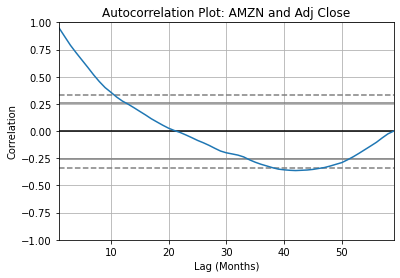

In [11]:
# Create the autocorrelation graph for Amazon.
#
my_stock_analyzer.plot_autocorrelation_graph("AMZN", "Adj Close")

# The autocorrelation plot starts off with a high autocorrelation approaching 1 at the
# one month lag. However, after that, the plot declines over the next several months until it
# becomes negative after month 20.  It continues to decline, showing an increasing negative
# correlation, until month 40 when it starts increasing again.  The decrease of the line seems
# to be mostly linear until month 40.  However, after month 10 it enters the 'Confidence 
# Interval' zone as most of the observations in this Confidence Interval zone around 0 can be 
# considered statistically insignificant.
#
# Therefore, in summary, the adjusted close has a predictability until month 10 as the points
# are statistically significant.  After that, the remaining points are statistically insginifiant
# as they are within the Confidence Interval bands.
# I wouldn't suspect that this has a high autocorrelation as, even though
# it looks like there is a linear pattern to it for the first 3 1/2 years, most of it is not
# a strong correlation (e.g., 1) but rather statistically insignificant and therefore, one 
# can't necessary predict its future.


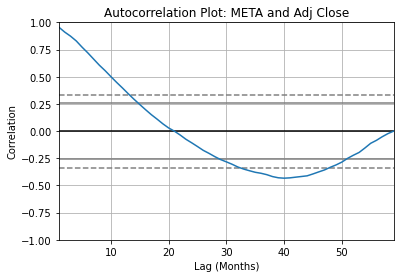

In [12]:
# Create the autocorrelation graph for Meta.
#
my_stock_analyzer.plot_autocorrelation_graph("META", "Adj Close")

# The autocorrelation plot starts off with a high autocorrelation approaching 1 at the
# one month lag. However, after that, the plot declines over the next several months until it
# becomes negative after month 20 (similar to AMAZON).  It continues to decline, showing an 
# increasing negative correlation, until month 40 when it starts increasing again.  
# The decrease of the line seems to be mostly linear until month 40.  However, after month 15 
# it enters the 'Confidence Interval' zone as most of the observations in this Confidence 
# Interval zone around 0 can be considered statistically insignificant.
#
# Therefore, in summary, I wouldn't suspect that this has a high autocorrelation as, even though
# it looks like there is a linear pattern to it for the first 3 1/2 years, most of it is not
# a strong correlation (e.g., 1) but rather statistically insignificant and therefore, one 
# can't necessary predict its future.

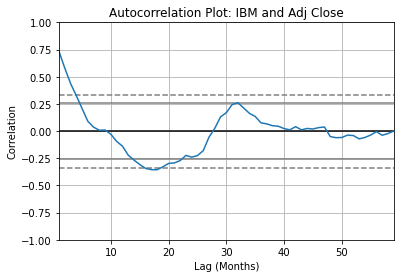

In [13]:
# Create the autocorrelation graph for IBM.
#
my_stock_analyzer.plot_autocorrelation_graph("IBM", "Adj Close")

# This is a different autocorrelation plot than what was seen with Amazon and Meta.
# The autocorrelation plots starts off with an autocorrelation approaching .75 at the
# one month lag. However, after that, the plot quickly declines over the next few months until it
# becomes negative after month 5 (it was around month 20 for both Amazon and Meta).  
# It continues to decline until month 17 showing an increasing negative correlation.
# It then increases, showing a positive correlation until just after month 30, after which
# it essentially levels off around 0.  However, after month 5, it enters the 'Confidence 
# Interval' zone as most of the observations in this Confidence Interval zone around 0 can be 
# considered statistically insignificant.
#
# Therefore, in summary, this does not have a high autocorrelation as most of the plot is not
# a strong correlation (e.g., 1) but rather statistically insignificant and therefore, one 
# can't necessary predict its future.

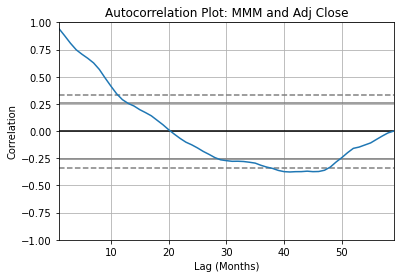

In [14]:
# Create the autocorrelation graph for IBM.
#
my_stock_analyzer.plot_autocorrelation_graph("MMM", "Adj Close")

# The autocorrelation plot starts off with a high autocorrelation approaching 1 at the
# one month lag. However, after that, the plot declines over the next several months until it
# becomes negative after month 20 (similar to AMAZON).  It continues to decline, showing an 
# increasing negative correlation, until month 40 when it starts increasing again.  
# The decrease of the line seems to be mostly linear until month 40.  However, after month 15 
# it enters the 'Confidence Interval' zone as most of the observations in this Confidence 
# Interval zone around 0 can be considered statistically insignificant.
#
# Therefore, in summary, I wouldn't suspect that this has a high autocorrelation as, even though
# it looks like there is a linear pattern to it for the first 3 1/2 years, most of it is not
# a strong correlation (e.g., 1) but rather statistically insignificant and therefore, one 
# can't necessary predict its future.

In [15]:
# Add the Return on Investment / Month column.
#
my_stock_analyzer.add_roi()

# Check to make sure the columns were added and the first Last Month column
# is set to the first Adj Close to get an ROI of 0%.
#
my_stock_analyzer.print_stock("AMZN", 10)


Looking for  AMZN in: ['AMZN', 'META', 'IBM', 'MMM']
        Date  Adj Close Stock  LastMonth  MonthlyROI
0 2013-11-29  19.681000  AMZN  19.681000    0.000000
1 2013-12-31  19.939501  AMZN  19.681000    1.313455
2 2014-01-31  17.934500  AMZN  19.939501  -10.055423
3 2014-02-28  18.105000  AMZN  17.934500    0.950681
4 2014-03-31  16.818501  AMZN  18.105000   -7.105767
5 2014-04-30  15.206500  AMZN  16.818501   -9.584686
6 2014-05-30  15.627500  AMZN  15.206500    2.768550
7 2014-06-30  16.239000  AMZN  15.627500    3.912979
8 2014-07-31  15.649500  AMZN  16.239000   -3.630152
9 2014-08-29  16.952000  AMZN  15.649500    8.322948


In [16]:
# Ensure that none of the stock dataframes have incomplete columns.
#
for stock in my_stock_list:
    my_stock_analyzer.identify_incomplete_column_data(stock)


----------------------------

Date          0
Adj Close     0
Stock         0
LastMonth     0
MonthlyROI    0
dtype: int64
----------------------------
----------------------------

Date          0
Adj Close     0
Stock         0
LastMonth     0
MonthlyROI    0
dtype: int64
----------------------------
----------------------------

Date          0
Adj Close     0
Stock         0
LastMonth     0
MonthlyROI    0
dtype: int64
----------------------------
----------------------------

Date          0
Adj Close     0
Stock         0
LastMonth     0
MonthlyROI    0
dtype: int64
----------------------------


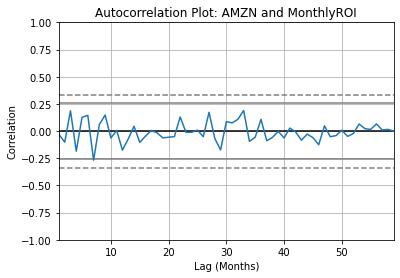

In [17]:
# Create the autocorrelation graph for IBM.
#
my_stock_analyzer.plot_autocorrelation_graph("AMZN", "MonthlyROI")

# The autocorrelation plot starts off close to 0 and remains within the Confidence Interval
# band for the entirety of the time series.  Therefore, as these points are statistically
# insignificant, there is no correlation between the monthly Return on Investments (ROI) for
# Amazon.  This would be as expected.


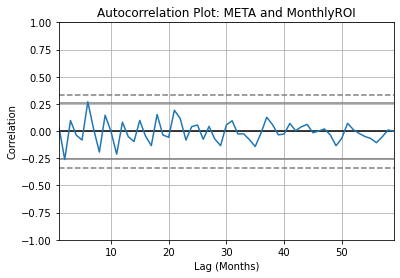

In [18]:
# Create the autocorrelation graph for IBM.
#
my_stock_analyzer.plot_autocorrelation_graph("META", "MonthlyROI")

# The autocorrelation plot starts off close to 0 and remains within the Confidence Interval
# band for the entirety of the time series.  Therefore, as these points are statistically
# insignificant, there is no correlation between the monthly Return on Investments (ROI) for
# Meta.  This would be as expected.


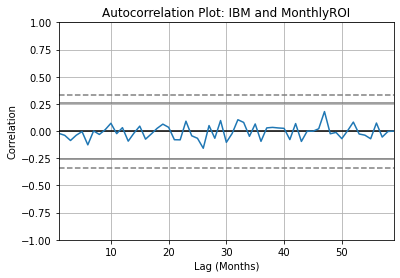

In [19]:
# Create the autocorrelation graph for IBM.
#
my_stock_analyzer.plot_autocorrelation_graph("IBM", "MonthlyROI")

# The autocorrelation plot starts off close to 0 and remains within the Confidence Interval
# band for the entirety of the time series.  Therefore, as these points are statistically
# insignificant, there is no correlation between the monthly Return on Investments (ROI) for
# IBM.  This would be as expected.


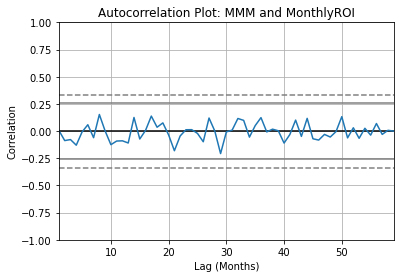

In [20]:
# Create the autocorrelation graph for IBM.
#
my_stock_analyzer.plot_autocorrelation_graph("MMM", "MonthlyROI")

# The autocorrelation plot starts off close to 0 and remains within the Confidence Interval
# band for the entirety of the time series.  Therefore, as these points are statistically
# insignificant, there is no correlation between the monthly Return on Investments (ROI) for
# 3M.  This would be as expected.


In [21]:
# To merge all the stocks together, conduct a Vertical Concatenate.
#
my_stock_analyzer.merge_all_stocks()
my_stock_analyzer.get_dataframe_all_stocks().head()


,Date,Adj Close,Stock,LastMonth,MonthlyROI
0,2013-11-29,19.681000,AMZN,19.681000,0.000000
1,2013-12-31,19.939501,AMZN,19.681000,1.313455
2,2014-01-31,17.934500,AMZN,19.939501,-10.055423
3,2014-02-28,18.105000,AMZN,17.934500,0.950681
4,2014-03-31,16.818501,AMZN,18.105000,-7.105767


In [22]:
# To merge all the stock ROIs together, conduct a Horizontal Concatenate.
# Note that ROIs for month 0 is '0' based on the impute logic (i.e., too difficult to 
# accurately predict an ROI for any particular month so setting it to 0%).
#
my_stock_analyzer.merge_all_stocks_roi()
my_stock_analyzer.get_dataframe_all_roi().head()

,AMZN ROI,META ROI,IBM ROI,MMM ROI
0,0.000000,0.000000,0.000000,0.000000
1,1.313455,16.251869,4.391128,5.048301
2,-10.055423,14.492219,-5.805839,-8.598932
3,0.950681,9.413456,5.379862,5.792406
4,-7.105767,-12.007008,3.953092,0.690258


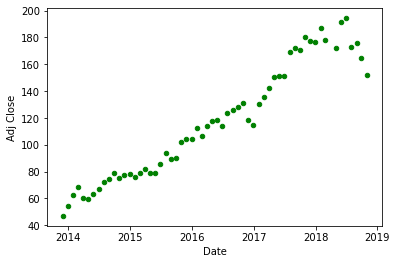

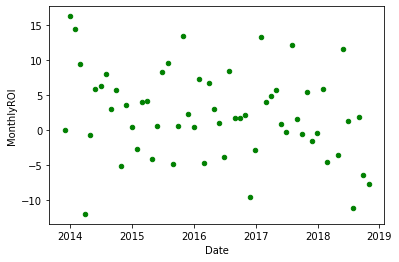

In [23]:
# Print out scatter plots for META.
#
my_stock_analyzer.print_scatter_plot("META", 'Adj Close')
my_stock_analyzer.print_scatter_plot("META", 'MonthlyROI')

# For the Adj Close scatter plot, a linear function appears to be present from 2014 to 2018.
# Therefore, there is predictivity on Adjusted Close between those dates.
#
# For the MonthlyROI scatter plot, there doesn't appear to be any linear function at all and
# therefore, we would not be able to make predictions.

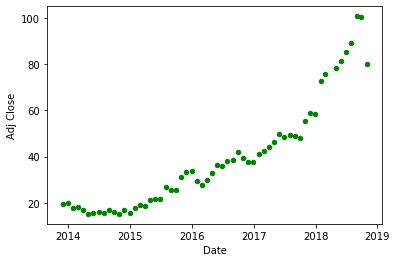

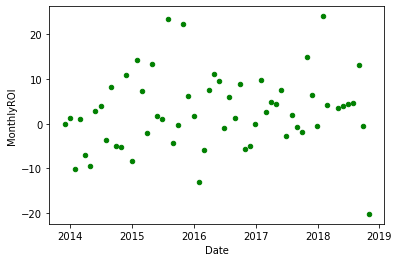

In [24]:
# Print out scatter plots for AMZN.
#
my_stock_analyzer.print_scatter_plot("AMZN", 'Adj Close')
my_stock_analyzer.print_scatter_plot("AMZN", 'MonthlyROI')

# For the Adj Close scatter plot, an exponential function appears to be present from 2014 to 
# midway through 2018.  Therefore, there is predictivity on Adjusted Close between those dates.
#
# For the MonthlyROI scatter plot, there doesn't appear to be any linear function at all and
# therefore, we would not be able to make predictions.


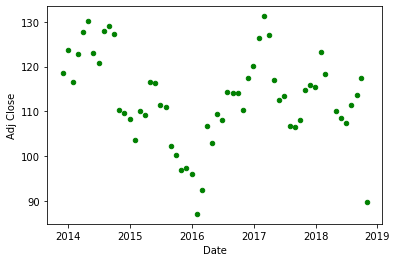

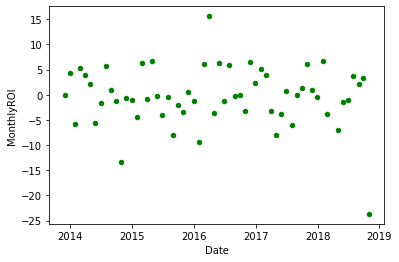

In [25]:
# Print out scatter plots for IBM.
#
my_stock_analyzer.print_scatter_plot("IBM", 'Adj Close')
my_stock_analyzer.print_scatter_plot("IBM", 'MonthlyROI')

# For the Adj Close scatter plot, there is no linear relationship present.  Therefore there is
# no predictivity on Adjusted Close for the Time Series.
#
# For the MonthlyROI scatter plot, there doesn't appear to be any linear function at all and
# therefore, we would not be able to make predictions.


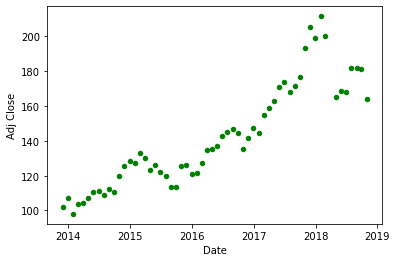

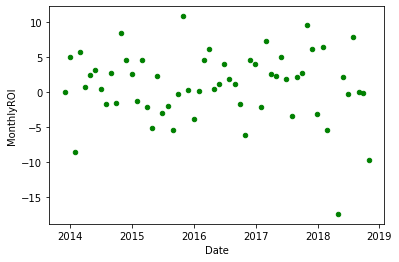

In [26]:
# Print out scatter plots for MMM.
#
my_stock_analyzer.print_scatter_plot("MMM", 'Adj Close')
my_stock_analyzer.print_scatter_plot("MMM", 'MonthlyROI')

# For the Adj Close scatter plot, a linear function appears to be present from 2014 to 2018.
# Therefore, there is predictivity on Adjusted Close between those dates.
#
# For the MonthlyROI scatter plot, there doesn't appear to be any linear function at all and
# therefore, we would not be able to make predictions.

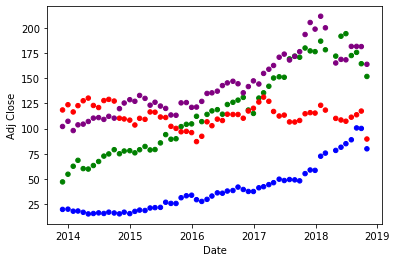

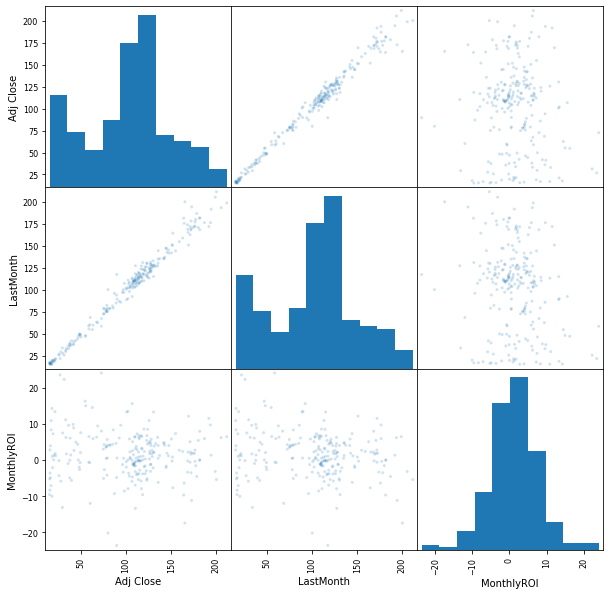

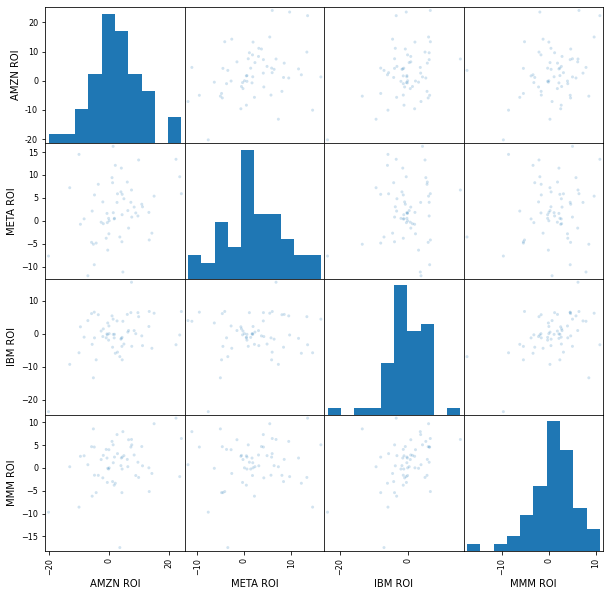

In [27]:
# Print out the scatter matrix for all stocks.
#
my_stock_analyzer.print_scatter_matrix(0)
my_stock_analyzer.print_scatter_matrix_roi()

# Blue - Amazon
# Green - META
# Red - IBM
# Purple - MMM


In [28]:

# For the top scatter plots on the pairs of fields (e.g., Adjusted Close, LastMonth and 
# MonthlyROI), there is only one correlation between Last Month and Adjusted Close.  This
# can be explained as the data had been shifted one time unit where the Adjusted Close of one
# month becomes the Last Month value of the next month.  That is why there is such a strong
# correlation.
#
# For the bottom scatter plots on the pairs of fields (e.g., AMZN ROI, META ROI, IBM ROI and
# MMM ROI), there doesn't appear to be any correlation between any of the pairs.
# The closest is the MMM-IBM pair but a predictable model would not be able to be applied to
# this pairing based on the scatter plot.
